# Phase 1: Data Preparation — BraTS 2025

The dataset is **already preprocessed** (skull-stripped, registered, normalized to [0,1]).

**What this notebook does:**
1. Load `.npy` volumes (128×128×128×4 — 4 modalities)
2. Apply **CLAHE contrast enhancement** per modality per slice
3. Extract 2D axial slices (128×128)
4. Process masks into ET/TC/WT sub-regions
5. Save everything for GAN training

**Dataset:**
- Images: `(128, 128, 128, 4)` float64 range [0,1]
- Masks: `(128, 128, 128, 4)` binary {0,1}
- 66 train / val / test split

In [1]:
!pip install numpy
!pip install matplotlib
!pip install opencv-python
!pip install tqdm

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 1.26.4

    Uninstalling numpy-1.26.4:

   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
      Successfully uninstalled numpy-1.26.4
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   

In [ ]:

import os
import numpy as np
import cv2
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════
#  PATHS — Match your Kaggle dataset structure
# ══════════════════════════════════════════════════════════════════════════
BASE_DATA = r"F:\shn\archive"

TRAIN_IMG = os.path.join(BASE_DATA, "train/images")
TRAIN_MSK = os.path.join(BASE_DATA, "train/masks")
VAL_IMG   = os.path.join(BASE_DATA, "val/images")
VAL_MSK   = os.path.join(BASE_DATA, "val/masks")
TEST_IMG  = os.path.join(BASE_DATA, "test/images")
TEST_MSK  = os.path.join(BASE_DATA, "test/masks")

# Output directory
OUTPUT_DIR = r"C:\Users\Admin\processed_data"      
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify
for d in [TRAIN_IMG, TRAIN_MSK, VAL_IMG, VAL_MSK, TEST_IMG, TEST_MSK]:
    n = len(os.listdir(d)) if os.path.exists(d) else 0
    print(f"  {d.split('glioma split data/')[-1]:30s} → {n} files")

  C:\Users\Admin\Downloads\archive\glioma split data\train/images → 66 files
  C:\Users\Admin\Downloads\archive\glioma split data\train/masks → 66 files
  C:\Users\Admin\Downloads\archive\glioma split data\val/images → 13 files
  C:\Users\Admin\Downloads\archive\glioma split data\val/masks → 13 files
  C:\Users\Admin\Downloads\archive\glioma split data\test/images → 9 files
  C:\Users\Admin\Downloads\archive\glioma split data\test/masks → 9 files


---
## Step 0: Inspect the Data

In [3]:
# Load one sample to understand the structure
sample_img = np.load(os.path.join(TRAIN_IMG, "image_0.npy"))
sample_msk = np.load(os.path.join(TRAIN_MSK, "mask_0.npy"))

print(f"Image shape: {sample_img.shape}  dtype: {sample_img.dtype}  range: [{sample_img.min():.4f}, {sample_img.max():.4f}]")
print(f"Mask shape:  {sample_msk.shape}  dtype: {sample_msk.dtype}  unique: {np.unique(sample_msk)}")
print()

# Check what each mask channel represents
print("Mask channel analysis:")
for ch in range(sample_msk.shape[-1]):
    vol = sample_msk[:, :, :, ch]
    n_pos = (vol > 0).sum()
    pct = n_pos / vol.size * 100
    print(f"  Channel {ch}: {n_pos:,} positive voxels ({pct:.2f}%)")

print()
print("Image channel analysis (per modality):")
MODALITY_NAMES = ["T1", "T1c", "T2", "FLAIR"]  # typical BraTS order
for ch in range(sample_img.shape[-1]):
    vol = sample_img[:, :, :, ch]
    print(f"  Channel {ch} ({MODALITY_NAMES[ch]}): mean={vol.mean():.4f}  std={vol.std():.4f}  nonzero={np.count_nonzero(vol)/vol.size*100:.1f}%")

Image shape: (128, 128, 128, 4)  dtype: float64  range: [0.0000, 1.0000]
Mask shape:  (128, 128, 128, 4)  dtype: float64  unique: [0. 1.]

Mask channel analysis:
  Channel 0: 2,056,568 positive voxels (98.06%)
  Channel 1: 1,717 positive voxels (0.08%)
  Channel 2: 32,773 positive voxels (1.56%)
  Channel 3: 6,094 positive voxels (0.29%)

Image channel analysis (per modality):
  Channel 0 (T1): mean=0.2896  std=0.2604  nonzero=59.4%
  Channel 1 (T1c): mean=0.2445  std=0.2202  nonzero=59.4%
  Channel 2 (T2): mean=0.3362  std=0.3177  nonzero=59.4%
  Channel 3 (FLAIR): mean=0.2315  std=0.2258  nonzero=59.4%


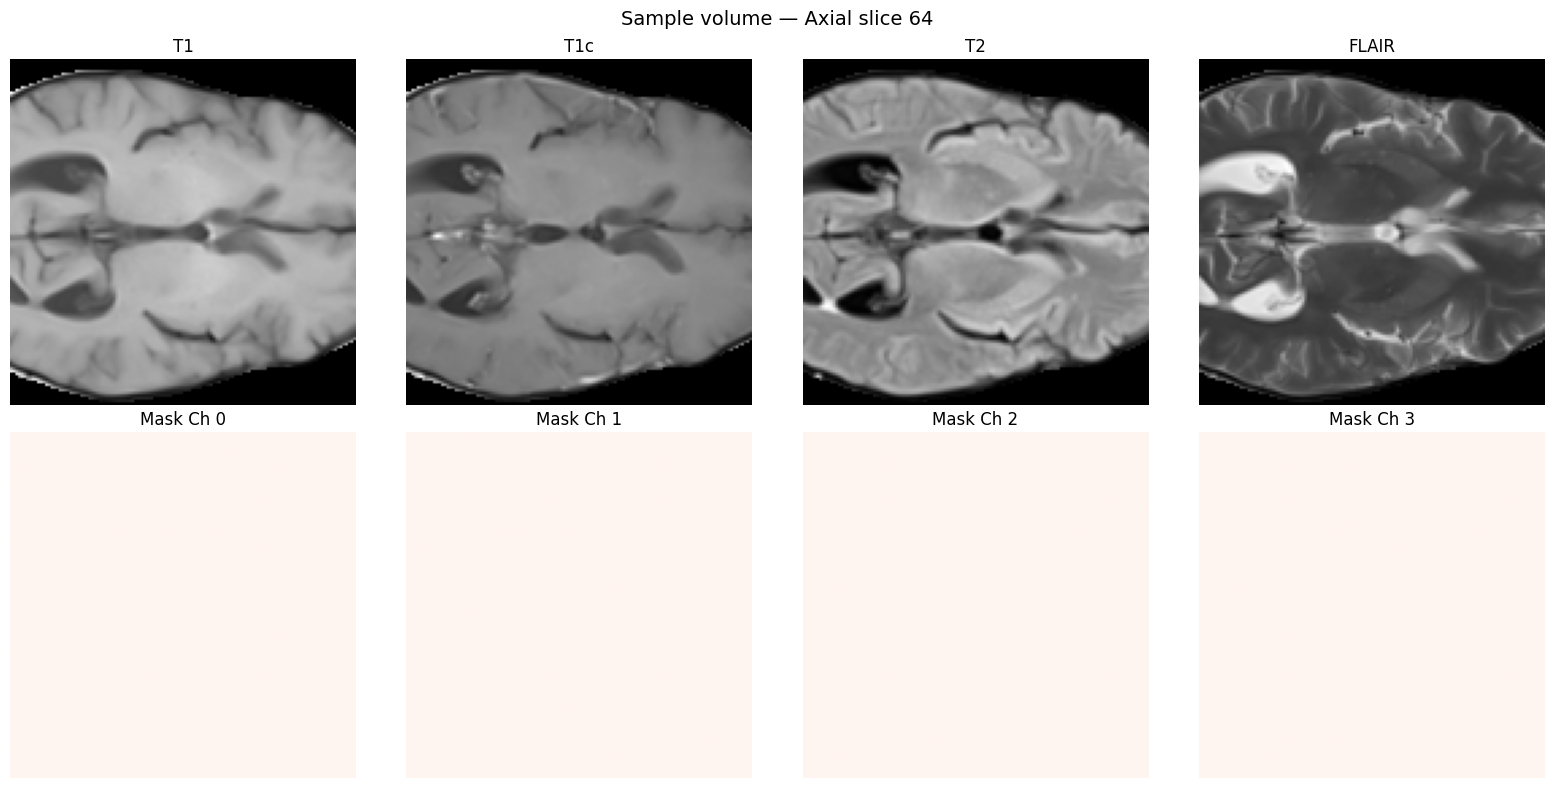

In [4]:
# Visualise one axial slice across all modalities + mask channels
slice_idx = 64  # middle slice

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ch in range(4):
    axes[0, ch].imshow(sample_img[:, :, slice_idx, ch], cmap="gray")
    axes[0, ch].set_title(f"{MODALITY_NAMES[ch]}")
    axes[0, ch].axis("off")
    
    axes[1, ch].imshow(sample_msk[:, :, slice_idx, ch], cmap="Reds")
    axes[1, ch].set_title(f"Mask Ch {ch}")
    axes[1, ch].axis("off")

plt.suptitle(f"Sample volume — Axial slice {slice_idx}", fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 1: CLAHE Contrast Enhancement

**Contrast Limited Adaptive Histogram Equalization** is applied to each 2D axial slice of each modality independently.

- **Clip limit:** 2.0
- **Tile grid:** 8×8
- Boosts local contrast in low-contrast tumor boundaries

In [5]:
def apply_clahe_slice(slice_2d, clip_limit=2.0, tile_grid=(8, 8)):
    """
    Apply CLAHE to a single 2D slice.
    Input: float array [0, 1]. Rescaled internally to uint8 for OpenCV.
    """
    smin, smax = slice_2d.min(), slice_2d.max()
    if smax - smin < 1e-8:
        return slice_2d  # uniform slice — skip
    
    # Rescale to 0–255 uint8
    normed = ((slice_2d - smin) / (smax - smin) * 255).astype(np.uint8)
    
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    enhanced = clahe.apply(normed)
    
    # Map back to original [0, 1] range
    out = enhanced.astype(np.float32) / 255.0 * (smax - smin) + smin
    return out


def apply_clahe_volume(volume_4d, clip_limit=2.0, tile_grid=(8, 8)):
    """
    Apply CLAHE to a (128, 128, 128, 4) volume.
    Processes each modality channel and each axial slice independently.
    """
    out = volume_4d.astype(np.float32).copy()
    H, W, D, C = out.shape
    
    for ch in range(C):            # per modality
        for z in range(D):         # per axial slice
            s2d = out[:, :, z, ch]
            if s2d.max() - s2d.min() > 1e-8:
                out[:, :, z, ch] = apply_clahe_slice(s2d, clip_limit, tile_grid)
    
    return out


# Quick test
test_enhanced = apply_clahe_volume(sample_img)
print(f"Enhanced shape: {test_enhanced.shape}  range: [{test_enhanced.min():.4f}, {test_enhanced.max():.4f}]")
print("✓ CLAHE function ready.")

Enhanced shape: (128, 128, 128, 4)  range: [0.0039, 1.0000]
✓ CLAHE function ready.


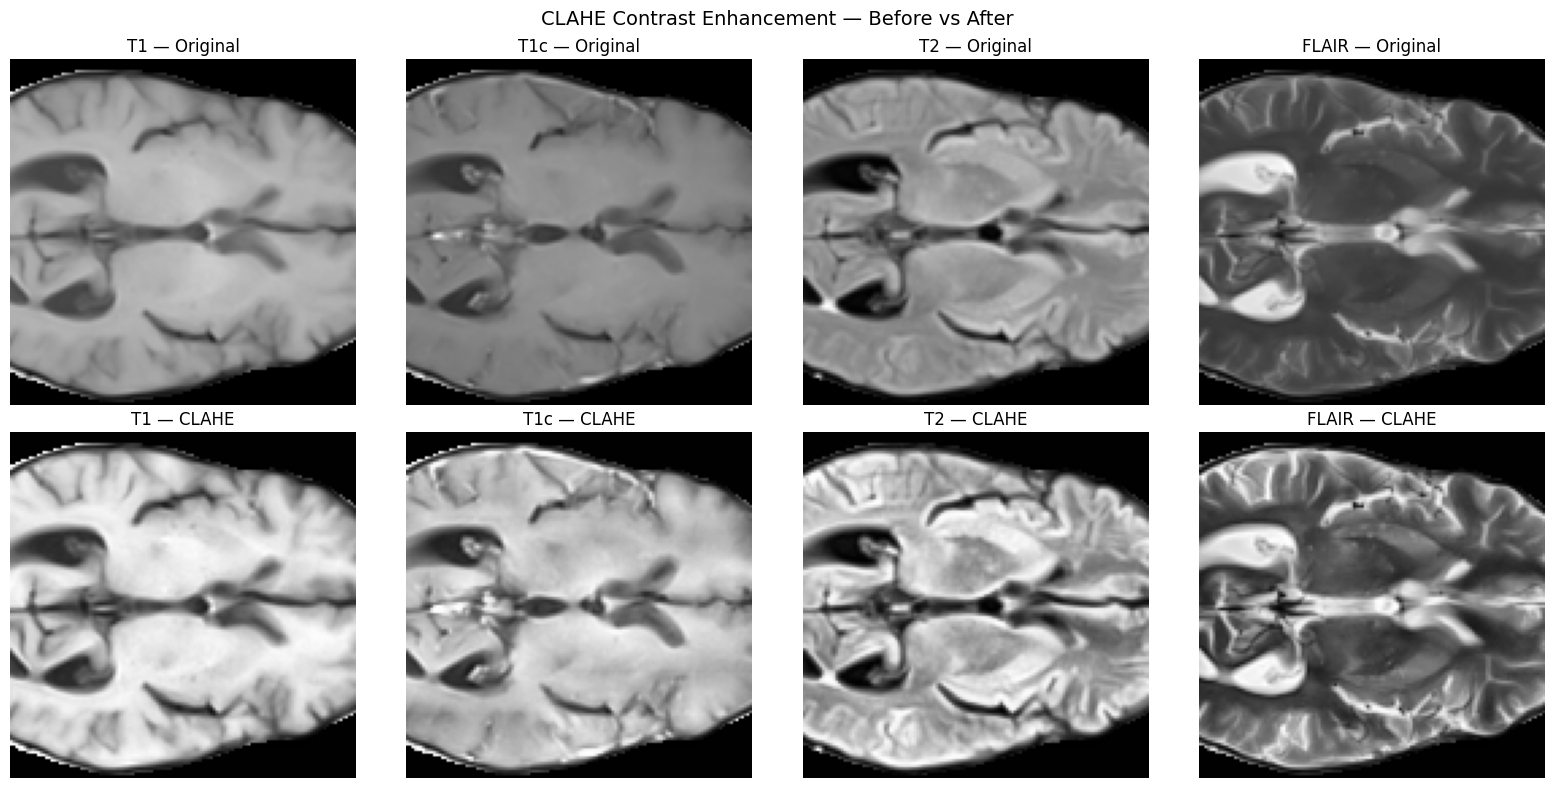

In [6]:
# Visualise CLAHE before/after
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
slice_idx = 64

for ch in range(4):
    axes[0, ch].imshow(sample_img[:, :, slice_idx, ch], cmap="gray")
    axes[0, ch].set_title(f"{MODALITY_NAMES[ch]} — Original")
    axes[0, ch].axis("off")
    
    axes[1, ch].imshow(test_enhanced[:, :, slice_idx, ch], cmap="gray")
    axes[1, ch].set_title(f"{MODALITY_NAMES[ch]} — CLAHE")
    axes[1, ch].axis("off")

plt.suptitle("CLAHE Contrast Enhancement — Before vs After", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "clahe_comparison.png"), dpi=150)
plt.show()

---
## Step 2: Extract 2D Axial Slices + Build ROI Masks

For each volume:
1. Apply CLAHE to all 4 modalities
2. Extract 128 axial slices (128×128 each)
3. Filter out near-empty slices
4. Build ROI masks from the 4 mask channels
5. Save as individual `.npy` files

In [7]:
def process_split(img_dir, mask_dir, output_name, min_brain_frac=0.02, clip_limit=2.0):
    """
    Process one data split (train/val/test):
    - Apply CLAHE
    - Extract 2D axial slices per modality
    - Build per-slice masks
    - Save to /kaggle/working/processed/{split}/
    """
    # Output directories
    out_slices = os.path.join(OUTPUT_DIR, output_name, "slices")
    out_masks  = os.path.join(OUTPUT_DIR, output_name, "masks")
    os.makedirs(out_slices, exist_ok=True)
    os.makedirs(out_masks, exist_ok=True)
    
    img_files = sorted(Path(img_dir).glob("*.npy"))
    mask_files = sorted(Path(mask_dir).glob("*.npy"))
    
    total_slices = 0
    total_with_tumor = 0
    
    for img_path, mask_path in tqdm(zip(img_files, mask_files), total=len(img_files), desc=output_name):
        # Load
        vol = np.load(str(img_path))    # (128, 128, 128, 4)
        msk = np.load(str(mask_path))   # (128, 128, 128, 4)
        
        # Get volume ID from filename
        vol_id = img_path.stem.replace("image_", "")
        
        # Apply CLAHE
        vol = apply_clahe_volume(vol, clip_limit=clip_limit)
        
        H, W, D, C = vol.shape
        
        for z in range(D):  # each axial slice
            # Image slice: all 4 modalities → (4, 128, 128)
            img_slice = vol[:, :, z, :].transpose(2, 0, 1).astype(np.float32)  # (4, H, W)
            
            # Skip near-empty slices (check across all modalities)
            brain_frac = np.count_nonzero(img_slice) / img_slice.size
            if brain_frac < min_brain_frac:
                continue
            
            # Mask slice: all 4 channels → (4, 128, 128)
            mask_slice = msk[:, :, z, :].transpose(2, 0, 1).astype(np.float32)  # (4, H, W)
            
            # Save
            fname = f"vol{vol_id}_slice{z:03d}"
            np.save(os.path.join(out_slices, f"{fname}.npy"), img_slice)
            np.save(os.path.join(out_masks, f"{fname}.npy"), mask_slice)
            
            total_slices += 1
            if mask_slice.sum() > 0:
                total_with_tumor += 1
    
    print(f"  ✓ {output_name}: {total_slices} slices saved ({total_with_tumor} with tumor)")
    return total_slices

print("✓ Processing function ready.")

✓ Processing function ready.


In [8]:
# ── Process all splits ────────────────────────────────────────────────────
n_train = process_split(TRAIN_IMG, TRAIN_MSK, "train")
n_val   = process_split(VAL_IMG,   VAL_MSK,   "val")
n_test  = process_split(TEST_IMG,  TEST_MSK,  "test")
print(f"\n{'='*50}")
print(f"Total slices — Train: {n_train}  Val: {n_val}  Test: {n_test}")
print(f"Output: {OUTPUT_DIR}")

train:   0%|          | 0/66 [00:00<?, ?it/s]

  ✓ train: 8382 slices saved (8382 with tumor)


val:   0%|          | 0/13 [00:00<?, ?it/s]

  ✓ val: 1662 slices saved (1662 with tumor)


test:   0%|          | 0/9 [00:00<?, ?it/s]

  ✓ test: 1138 slices saved (1138 with tumor)

Total slices — Train: 8382  Val: 1662  Test: 1138
Output: C:\Users\Admin\processed_data


---
## Step 3: Verify Processed Data

Processed train slices: 8382
Processed train masks:  8382

Slice shape: (4, 128, 128)  Mask shape: (4, 128, 128)


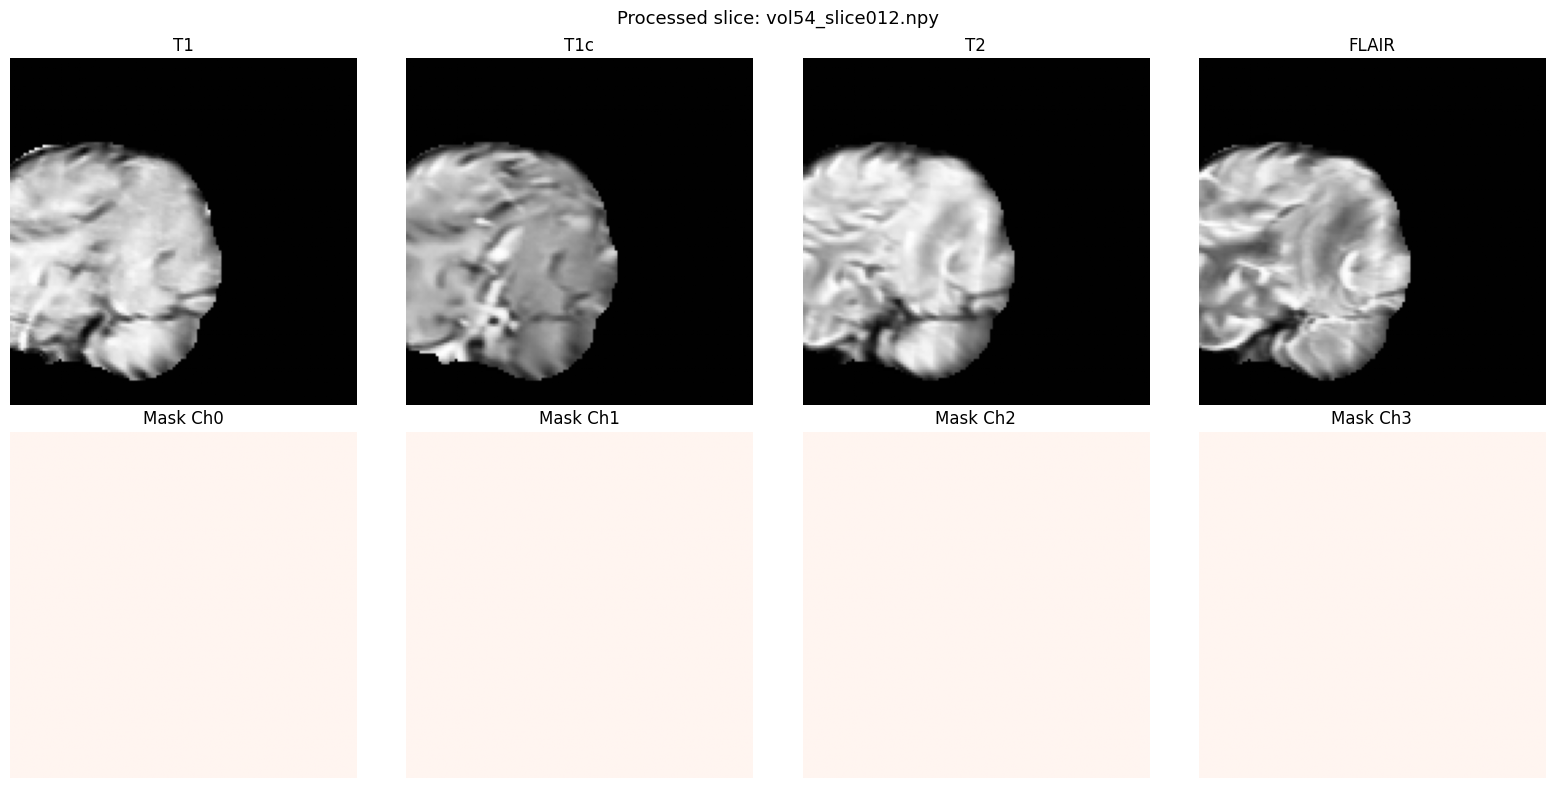

In [9]:
# Load and visualise a processed slice
proc_slices = sorted(Path(os.path.join(OUTPUT_DIR, "train/slices")).glob("*.npy"))
proc_masks  = sorted(Path(os.path.join(OUTPUT_DIR, "train/masks")).glob("*.npy"))

print(f"Processed train slices: {len(proc_slices)}")
print(f"Processed train masks:  {len(proc_masks)}")

if proc_slices:
    s = np.load(str(proc_slices[len(proc_slices)//2]))  # middle sample
    m = np.load(str(proc_masks[len(proc_masks)//2]))
    print(f"\nSlice shape: {s.shape}  Mask shape: {m.shape}")
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    titles_img = ["T1", "T1c", "T2", "FLAIR"]
    titles_msk = ["Mask Ch0", "Mask Ch1", "Mask Ch2", "Mask Ch3"]
    
    for ch in range(4):
        axes[0, ch].imshow(s[ch], cmap="gray"); axes[0, ch].set_title(titles_img[ch]); axes[0, ch].axis("off")
        axes[1, ch].imshow(m[ch], cmap="Reds");  axes[1, ch].set_title(titles_msk[ch]); axes[1, ch].axis("off")
    
    plt.suptitle(f"Processed slice: {proc_slices[len(proc_slices)//2].name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "processed_sample.png"), dpi=150)
    plt.show()

In [11]:
# Summary statistics
print("\n" + "="*60)
print("  PHASE 1 COMPLETE — Data Preparation")
print("="*60)
print(f"\n  Output directory: {OUTPUT_DIR}")
print(f"  Format: (4, 128, 128) per slice — 4 modalities")
print(f"  Masks:  (4, 128, 128) per slice — 4 binary channels")
print(f"  CLAHE:  Applied (clip_limit=2.0, tile=(8,8))")
print(f"\n  Ready for GAN training notebooks (02-05)")


  PHASE 1 COMPLETE — Data Preparation

  Output directory: C:\Users\Admin\processed_data
  Format: (4, 128, 128) per slice — 4 modalities
  Masks:  (4, 128, 128) per slice — 4 binary channels
  CLAHE:  Applied (clip_limit=2.0, tile=(8,8))

  Ready for GAN training notebooks (02-05)
